# Modelado de mezclas gaussianas y variables latentes en la operación de UrbanMove




## 1. Entorno de trabajo

En esta sección se importan las librerías necesarias para cargar, transformar y analizar los datos, además de las herramientas utilizadas para ajustar y visualizar el modelo de mezcla gaussiana.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from scipy.stats import multivariate_normal

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Carga de datos



Se trabaja con `processed.csv`, que corresponde a la muestra que el equipo depuró y validó estadísticamente. La muestra contiene 40 000 viajes, obtenidos mediante muestreo aleatorio simple a partir del dataset original de UrbanMove.

El procedimiento utilizado para obtener esta muestra se explica en el notebook de preprocesamiento. Para este análisis se toma directamente `processed.csv` como punto de partida.



In [2]:
df = pd.read_csv('processed.csv', index_col=0)
print(f"Registros: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head(3)


Registros: 40,000 | Columnas: 21


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,dia_semana_pickup,horas_pickup,dia_semana_dropoff,horas_dropoff,borough_pickup,district_pickup,borough_dropoff,district_dropoff,distancia_haversine_km,velocidad_promedio_kmh
970802,id3561642,1,2016-03-12 18:25:05,2016-03-12 18:30:38,1,-73.987946,40.743935,-73.979248,40.752480,N,...,Saturday,18,Saturday,18,Manhattan,105,Manhattan,105,1.199834,12.971179
1190423,id3811637,2,2016-04-13 18:17:29,2016-04-13 18:40:49,1,-73.986748,40.755871,-73.949692,40.784519,N,...,Wednesday,18,Wednesday,18,Manhattan,105,Manhattan,108,4.459326,11.466837
538016,id1822735,1,2016-06-25 10:03:28,2016-06-25 10:08:40,1,-73.955673,40.779434,-73.971214,40.786018,N,...,Saturday,10,Saturday,10,Manhattan,108,Manhattan,107,1.499389,17.300644


## 3. Construcción del espacio de variables

Para aplicar una mezcla gaussiana necesitamos definir las variables que van a representar cada viaje. En este caso buscamos que esas variables permitan diferenciar comportamientos de movilidad y, al mismo tiempo, que tengan una interpretación útil para la operación.

El bloque de segmentación por partición que realizó el equipo utiliza principalmente las coordenadas de recogida y destino. Por eso, aquí se decidió enfocarse en las características propias del viaje: cuándo ocurre, cuánto dura, qué distancia recorre y cuál es su velocidad promedio. De esta manera se evita repetir la misma información entre ambos análisis.

Se utilizan las siguientes cinco variables:

- **`horas_pickup`**: hora de recogida (0–23).
- **`is_weekend`**: indicador que toma el valor 1 cuando el viaje ocurre sábado o domingo y 0 en caso contrario. Se incluye porque el comportamiento de los viajes puede cambiar entre los días laborales y el fin de semana.
- **`trip_duration`, `distancia_haversine_km` y `velocidad_promedio_kmh`**: describen directamente el viaje.


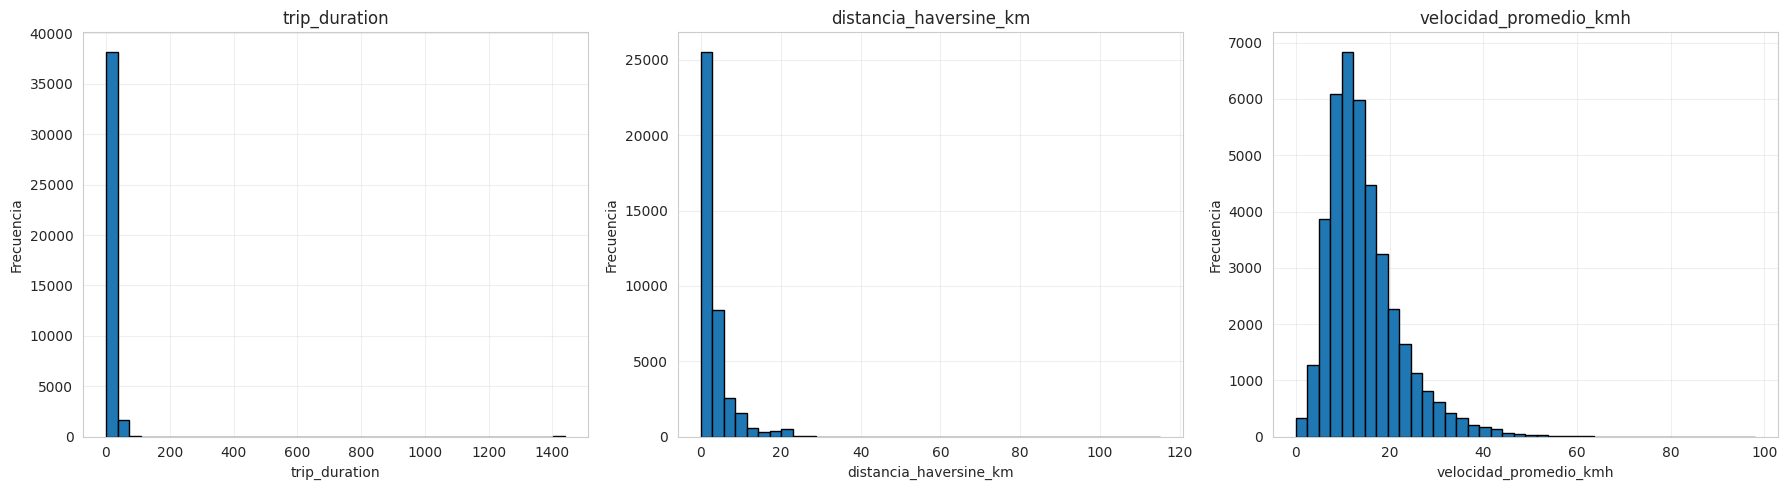

In [3]:
variables = [
    'trip_duration',
    'distancia_haversine_km',
    'velocidad_promedio_kmh'
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, variable in zip(axes, variables):
    ax.hist(df[variable].dropna(), bins=40, edgecolor='black')
    ax.set_title(variable)
    ax.set_xlabel(variable)
    ax.set_ylabel('Frecuencia')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
df['is_weekend'] = df['dia_semana_pickup'].isin(['Saturday', 'Sunday']).astype(int)

for col in ['trip_duration', 'distancia_haversine_km', 'velocidad_promedio_kmh']:
    print(f"Asimetría (skewness) de {col}: {df[col].skew():.2f}")


Asimetría (skewness) de trip_duration: 28.17
Asimetría (skewness) de distancia_haversine_km: 3.32
Asimetría (skewness) de velocidad_promedio_kmh: 1.47


Al revisar sus distribuciones se observa una asimetría importante, por lo que se utiliza la transformación $\log(1+x)$ antes de ajustar el modelo. Esto ayuda a reducir el efecto de las colas largas y hace que estas variables sean más adecuadas para el supuesto gaussiano del modelo.


Los tres coeficientes de asimetría son bastante mayores que 0, que sería el valor esperado para una distribución aproximadamente simétrica. Por esto, antes de continuar se aplica la transformación logarítmica a las tres variables.



In [5]:
df['log_duration'] = np.log1p(df['trip_duration'])
df['log_distancia'] = np.log1p(df['distancia_haversine_km'])
df['log_velocidad'] = np.log1p(df['velocidad_promedio_kmh'])

for col in ['log_duration', 'log_distancia', 'log_velocidad']:
    print(f"Asimetría de {col} tras la transformación log(1+x): {df[col].skew():.3f}")


Asimetría de log_duration tras la transformación log(1+x): 0.379
Asimetría de log_distancia tras la transformación log(1+x): 0.930
Asimetría de log_velocidad tras la transformación log(1+x): -0.461


Después de aplicar la transformación, la asimetría disminuye de manera importante en las tres variables. Esto indica que la transformación ayuda a obtener distribuciones menos sesgadas y, por tanto, más apropiadas para el modelo que se va a utilizar.



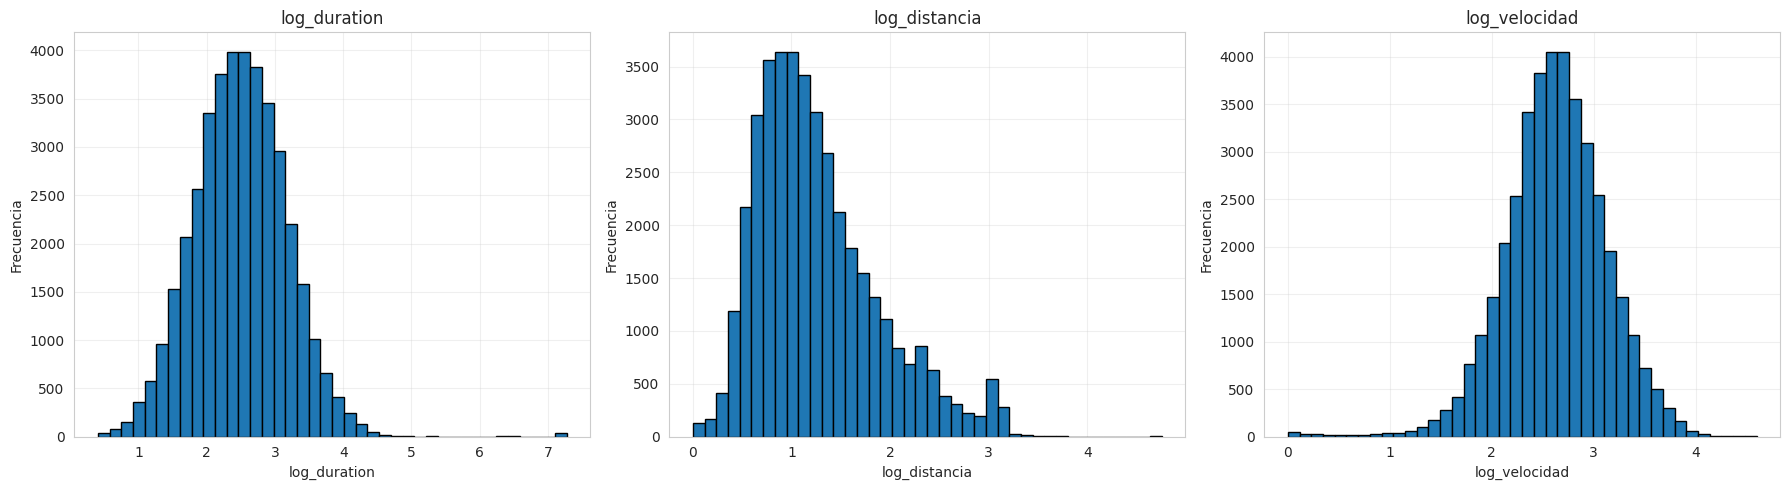

In [6]:
variables = [
    'log_duration',
    'log_distancia',
    'log_velocidad'
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, variable in zip(axes, variables):
    ax.hist(df[variable].dropna(), bins=40, edgecolor='black')
    ax.set_title(variable)
    ax.set_xlabel(variable)
    ax.set_ylabel('Frecuencia')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Identificación estadística de valores atípicos

Las mezclas gaussianas pueden verse afectadas por valores extremos, ya que una observación muy alejada del resto puede modificar las medias y covarianzas de los componentes. Por esta razón, antes de ajustar el modelo se identifican los posibles valores atípicos.

Se utiliza el criterio de Tukey sobre las variables logarítmicas (`log_duration`, `log_distancia`, `log_velocidad`). Trabajar sobre esta escala permite reducir primero la influencia de la asimetría que presentan las variables originales.

Un valor $x$ se considera un atípico extremo cuando cumple:

$$
x < Q_1 - 3 \cdot 	ext{IQR} \quad 	ext{o} \quad x > Q_3 + 3 \cdot 	ext{IQR}, \qquad 	ext{IQR} = Q_3 - Q_1
$$

Se utiliza $k=3$ en lugar del valor convencional $1.5$, ya que en este caso el objetivo es identificar observaciones realmente extremas y no eliminar viajes que simplemente se alejen un poco de la mediana. Por ejemplo, en una ciudad como Nueva York puede haber viajes largos o situaciones de tráfico poco frecuentes que sigan siendo completamente válidas.



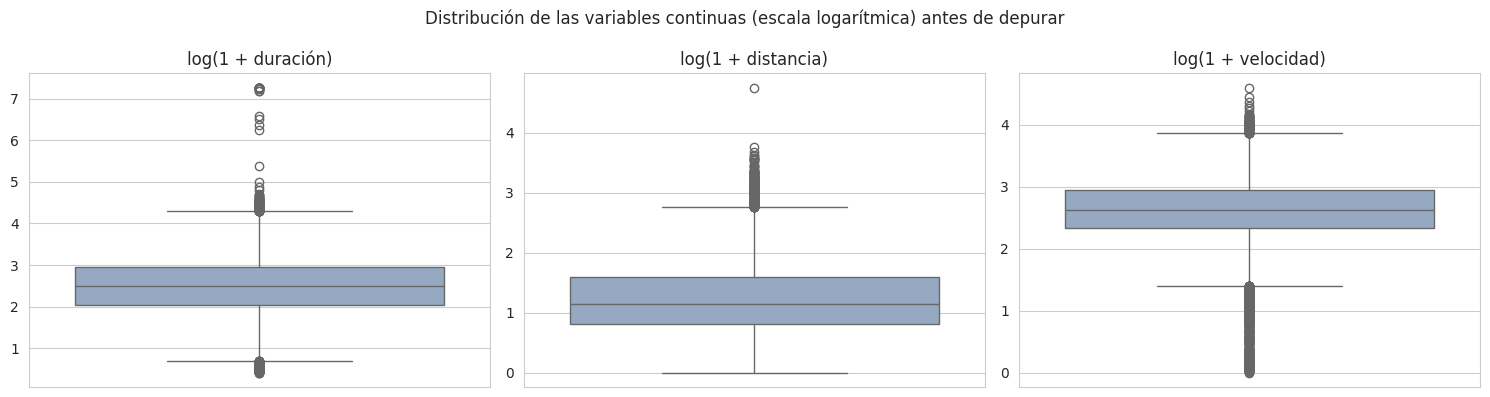

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, label in zip(axes,
                           ['log_duration', 'log_distancia', 'log_velocidad'],
                           ['log(1 + duración)', 'log(1 + distancia)', 'log(1 + velocidad)']):
    sns.boxplot(y=df[col], ax=ax, color='#8fa8c9')
    ax.set_title(label)
    ax.set_ylabel('')
plt.suptitle('Distribución de las variables continuas (escala logarítmica) antes de depurar')
plt.tight_layout()
plt.show()


In [8]:
log_cols = ['log_duration', 'log_distancia', 'log_velocidad']
bounds = {}
outlier_masks = []

for col in log_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 3 * iqr, q3 + 3 * iqr
    bounds[col] = (lower, upper)
    mask = (df[col] < lower) | (df[col] > upper)
    outlier_masks.append(mask)
    print(f"{col}: límites en escala log = ({lower:.3f}, {upper:.3f}) "
          f"→ escala original = ({np.expm1(lower):.3f}, {np.expm1(upper):.3f}) "
          f"| atípicos: {mask.sum()} ({mask.mean()*100:.2f}%)")

outlier_mask = outlier_masks[0] | outlier_masks[1] | outlier_masks[2]
print(f"\nUnión de atípicos en al menos una de las tres variables: "
      f"{outlier_mask.sum()} registros ({outlier_mask.mean()*100:.2f}% de la muestra)")


log_duration: límites en escala log = (-0.663, 5.647) → escala original = (-0.485, 282.460) | atípicos: 45 (0.11%)
log_distancia: límites en escala log = (-1.538, 3.940) → escala original = (-0.785, 50.406) | atípicos: 1 (0.00%)
log_velocidad: límites en escala log = (0.478, 4.790) → escala original = (0.613, 119.334) | atípicos: 122 (0.30%)

Unión de atípicos en al menos una de las tres variables: 125 registros (0.31% de la muestra)


Los límites obtenidos resultan razonables para los viajes analizados. Por ejemplo, viajes de hasta aproximadamente 280 minutos o 50 km todavía se encuentran dentro de un rango que puede considerarse plausible. En cambio, los registros que quedan fuera de estos límites presentan, en varios casos, duraciones muy altas combinadas con velocidades inferiores a 0.6 km/h. Este tipo de observaciones puede estar relacionado con problemas de registro, como un taxímetro que no se cerró correctamente o una pérdida de señal GPS.

La cantidad de registros eliminados es pequeña, inferior al 1 % de la muestra. Por lo tanto, la depuración no representa una reducción importante respecto a la muestra utilizada en el análisis.



In [9]:
df_clean = df[~outlier_mask].reset_index(drop=True)
print(f"Registros antes de depurar: {df.shape[0]:,}")
print(f"Registros después de depurar: {df_clean.shape[0]:,}")
print(f"Proporción retenida: {df_clean.shape[0] / df.shape[0] * 100:.2f}%")


Registros antes de depurar: 40,000
Registros después de depurar: 39,875
Proporción retenida: 99.69%


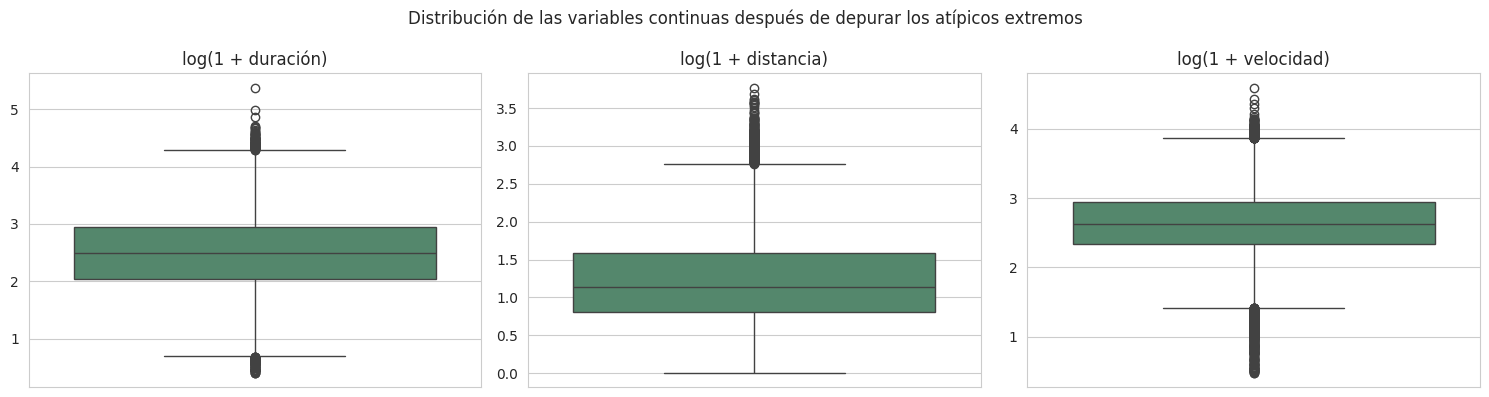

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, label in zip(axes,
                           ['log_duration', 'log_distancia', 'log_velocidad'],
                           ['log(1 + duración)', 'log(1 + distancia)', 'log(1 + velocidad)']):
    sns.boxplot(y=df_clean[col], ax=ax, color='#4c8f6b')
    ax.set_title(label)
    ax.set_ylabel('')
plt.suptitle('Distribución de las variables continuas después de depurar los atípicos extremos')
plt.tight_layout()
plt.show()


## 5. Matriz de diseño

Las cinco variables seleccionadas se estandarizan para que tengan media 0 y varianza 1 usando ```StandarScaler```.Esto evita que una variable tenga mayor influencia sobre el modelo simplemente porque está medida en una escala numéricamente más grande que las demás.



In [11]:
FEATURES = ['horas_pickup', 'is_weekend', 'log_duration', 'log_distancia', 'log_velocidad']

X = df_clean[FEATURES].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Matriz de diseño: {X_scaled.shape[0]:,} viajes × {X_scaled.shape[1]} variables")
features_summary = pd.DataFrame(X_scaled, columns=FEATURES).describe().round(2)
features_summary


Matriz de diseño: 39,875 viajes × 5 variables


,horas_pickup,is_weekend,log_duration,log_distancia,log_velocidad
count,39875.00,39875.00,39875.00,39875.00,39875.00
mean,-0.00,0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00
min,-2.12,-0.63,-3.18,-2.04,-4.50
25%,-0.71,-0.63,-0.68,-0.74,-0.63
50%,0.07,-0.63,-0.00,-0.20,0.00
75%,0.85,1.58,0.68,0.53,0.65
max,1.47,1.58,4.39,4.05,4.11


In [12]:
features_summary.to_csv('rol3_features_summary.csv')

## 6. El modelo de mezcla gaussiana

La idea del modelo es asumir que los viajes observados pueden venir de diferentes perfiles de movilidad. Cada perfil se representa mediante una distribución normal multivariada, y la distribución total de los datos es una combinación de esas distribuciones.

Para cada viaje $x_i \in \mathbb{R}^5$, el modelo se puede escribir como:

$$
p(x_i \mid \theta) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(x_i \mid \mu_k, \Sigma_k), \qquad \sum_{k=1}^K \pi_k = 1
$$

Aquí, $\pi_k$ representa el peso del perfil $k$, $\mu_k$ su vector de medias y $\Sigma_k$ su matriz de covarianza.

También existe una variable latente $z_i \in \{1,\dots,K\}$ que indica el perfil al que pertenece cada viaje, pero esta variable no se observa directamente. Solo tenemos los datos del viaje $x_i$. Esta es una diferencia importante frente a una segmentación rigida, en lugar de obligar a cada viaje a pertenecer a un único grupo, el GMM permite obtener una probabilidad de pertenencia para cada perfil.

La log-verosimilitud de los datos observados es:

$$
\ell(\theta) = \sum_{i=1}^{N} \log \left( \sum_{k=1}^{K} \pi_k \, \mathcal{N}(x_i \mid \mu_k, \Sigma_k) \right),
$$




## 7. Selección del número de perfiles

El número de componentes $K$ no está definido de antemano. Para elegirlo se comparan modelos con diferentes cantidades de componentes y se tiene en cuenta tanto la calidad del ajuste como la complejidad del modelo.

Para esto se utilizan los criterios BIC y AIC:

$$
\text{BIC} = -2\,\ell(\hat\theta) + p\log N, \qquad \text{AIC} = -2\,\ell(\hat\theta) + 2p
$$

En ambos casos, $p$ corresponde al número de parámetros libres del modelo y $N$ al número de observaciones. Se ajustan modelos con covarianza completa (`covariance_type='full'`) para valores de $K$ entre 2 y 8. Esta configuración permite que cada perfil tenga su propia matriz de covarianza y, por tanto, su propia estructura de relación entre las variables.



In [13]:
k_range = range(2, 9)
bic_scores, aic_scores = [], []

for k in k_range:
    gm_k = GaussianMixture(n_components=k, covariance_type='full', n_init=20,
                            random_state=RANDOM_STATE, max_iter=300)
    gm_k.fit(X_scaled)
    bic_scores.append(gm_k.bic(X_scaled))
    aic_scores.append(gm_k.aic(X_scaled))
    print(f"K={k}: BIC={gm_k.bic(X_scaled):>12,.1f} | AIC={gm_k.aic(X_scaled):>12,.1f} | converged={gm_k.converged_}")


K=2: BIC=  -131,224.4 | AIC=  -131,576.7 | converged=True
K=3: BIC=  -133,173.6 | AIC=  -133,706.4 | converged=True
K=4: BIC=  -203,271.2 | AIC=  -203,984.5 | converged=True
K=5: BIC=  -238,152.7 | AIC=  -239,046.4 | converged=True
K=6: BIC=  -256,261.4 | AIC=  -257,335.6 | converged=True
K=7: BIC=  -271,731.9 | AIC=  -272,986.6 | converged=True
K=8: BIC=  -283,550.9 | AIC=  -284,986.0 | converged=True


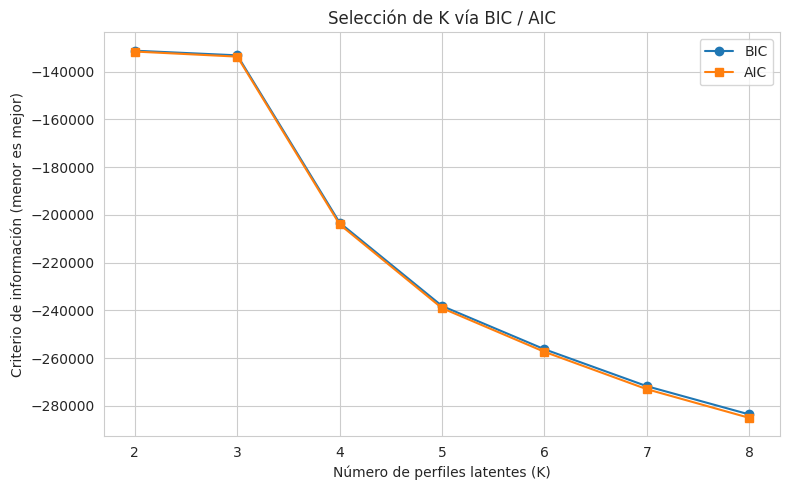

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), bic_scores, marker='o', label='BIC')
ax.plot(list(k_range), aic_scores, marker='s', label='AIC')
ax.set_xlabel('Número de perfiles latentes (K)')
ax.set_ylabel('Criterio de información (menor es mejor)')
ax.set_title('Selección de K vía BIC / AIC')
ax.legend()
plt.tight_layout()
plt.show()


En el rango de valores evaluado, ninguno de los dos criterios presenta un mínimo interno. Con la covarianza completa, agregar componentes sigue reduciendo los valores de BIC y AIC.

Como no aparece un punto de corte claro, se revisa cuánto mejora el BIC al agregar cada componente. La idea es encontrar un punto a partir del cual agregar más perfiles aporte relativamente poco frente al aumento de complejidad.



In [15]:
bic_series = pd.Series(bic_scores, index=list(k_range))
mejora_relativa = (bic_series.shift(1) - bic_series) / bic_series.shift(1).abs() * 100
tabla_mejora = pd.DataFrame({
    'BIC': bic_series.round(1),
    'Mejora relativa vs. K-1 (%)': mejora_relativa.round(1)
})
tabla_mejora


,BIC,Mejora relativa vs. K-1 (%)
2,-131224.4,NaN
3,-133173.6,1.5
4,-203271.2,52.6
5,-238152.7,17.2
6,-256261.4,7.6
7,-271731.9,6.0
8,-283550.9,4.3


In [16]:
tabla_mejora.to_csv('rol3_mejora_bic.csv')

La mejora relativa del BIC entre $K=3$ y $K=4$ (52.6%) es mayor que la observada entre $K=2$ y $K=3$ (1.5%). Después de $K=4$, las mejoras adicionales son más pequeñas.

Por esta razón se trabaja con **K = 4**.



## 8. El algoritmo EM — paso E: cálculo de responsabilidades

Como la variable $z_i$ no se observa, necesitamos un procedimiento que permita estimar simultáneamente los perfiles y la pertenencia de cada viaje. Para esto se utiliza el algoritmo **Expectation-Maximization (EM)**, que alterna dos pasos: E y M.

En el **paso E**, tomando los parámetros actuales $	heta^{(t)} = \{\pi_k, \mu_k, \Sigma_k\}$, se calcula la responsabilidad de cada perfil sobre cada viaje. Esta responsabilidad corresponde a la probabilidad posterior de que el viaje $i$ pertenezca al perfil $k$:

$$
\gamma_{ik} = p(z_i = k \mid x_i, \theta^{(t)}) = \frac{\pi_k^{(t)}\,\mathcal{N}(x_i\mid\mu_k^{(t)},\Sigma_k^{(t)})}{\displaystyle\sum_{j=1}^K \pi_j^{(t)}\,\mathcal{N}(x_i\mid\mu_j^{(t)},\Sigma_j^{(t)})}
$$

El valor $\gamma_{ik}$ está entre 0 y 1, y para un mismo viaje las responsabilidades de los $K$ perfiles suman 1. Así, un viaje puede tener una pertenencia clara a un perfil o quedar repartido entre varios.

Para comprobar el cálculo y no depender únicamente de `sklearn.mixture.GaussianMixture`, se toma un viaje de la muestra y se calcula manualmente su responsabilidad usando `scipy.stats.multivariate_normal`.



In [17]:
gm_probe = GaussianMixture(n_components=4, covariance_type='full', n_init=20,
                            init_params='k-means++', random_state=RANDOM_STATE, max_iter=500)
gm_probe.fit(X_scaled)

pi_k, mu_k, sigma_k = gm_probe.weights_, gm_probe.means_, gm_probe.covariances_

# Se selecciona un viaje cuya responsabilidad esté genuinamente repartida entre perfiles,
# para ilustrar el caso donde la pertenencia probabilística difiere de una asignación dura.
resp_todos = gm_probe.predict_proba(X_scaled)
entropia_resp = -(resp_todos * np.log(resp_todos + 1e-12)).sum(axis=1)
idx_ejemplo = int(np.argsort(entropia_resp)[-1])

print("Viaje seleccionado — atributos originales:")
print(df_clean.loc[idx_ejemplo, ['trip_duration', 'distancia_haversine_km',
                                   'velocidad_promedio_kmh', 'horas_pickup', 'dia_semana_pickup']])


Viaje seleccionado — atributos originales:
trip_duration                  4.85
distancia_haversine_km      1.98403
velocidad_promedio_kmh    24.544707
horas_pickup                      6
dia_semana_pickup         Wednesday
Name: 28898, dtype: object


In [18]:
x_i = X_scaled[idx_ejemplo]

densidades = np.array([
    multivariate_normal.pdf(x_i, mean=mu_k[k], cov=sigma_k[k]) for k in range(4)
])
numerador = pi_k * densidades
resp_manual = numerador / numerador.sum()
resp_sklearn = gm_probe.predict_proba(x_i.reshape(1, -1))[0]

tabla_verif = pd.DataFrame({
    'Perfil': [f'Perfil {k}' for k in range(4)],
    'gamma_ik (cálculo manual)': resp_manual.round(6),
    'predict_proba (sklearn)': resp_sklearn.round(6)
})
print(tabla_verif.to_string(index=False))
print(f"\nDiferencia máxima absoluta: {np.max(np.abs(resp_manual - resp_sklearn)):.2e}")


  Perfil  gamma_ik (cálculo manual)  predict_proba (sklearn)
Perfil 0                   0.269313                 0.269313
Perfil 1                   0.461870                 0.461870
Perfil 2                   0.268817                 0.268817
Perfil 3                   0.000000                 0.000000

Diferencia máxima absoluta: 2.45e-11


El cálculo manual coincide con el resultado de `predict_proba`. Esto permite comprobar que la fórmula utilizada en el paso E corresponde al cálculo que realiza la librería.

Además, el viaje seleccionado no queda asociado con una probabilidad cercana al 100 % a un solo perfil. Parte de su responsabilidad está distribuida entre varios componentes, lo que muestra de manera concreta la diferencia entre una mezcla gaussiana y una asignación rigida.

## 9. El algoritmo EM — paso M: actualización de parámetros

En el **paso M**, las responsabilidades calculadas en el paso anterior se utilizan para actualizar los parámetros del modelo. Si definimos el tamaño efectivo del perfil $k$ como $N_k = \sum_{i=1}^N \gamma_{ik}$, las actualizaciones son:

$$
\pi_k^{(t+1)} = \frac{N_k}{N}, \qquad
\mu_k^{(t+1)} = \frac{1}{N_k}\sum_{i=1}^N \gamma_{ik}\, x_i, \qquad
\Sigma_k^{(t+1)} = \frac{1}{N_k}\sum_{i=1}^N \gamma_{ik}\,(x_i-\mu_k^{(t+1)})(x_i-\mu_k^{(t+1)})^T
$$

Una propiedad de EM es que, al alternar los pasos E y M, la log-verosimilitud no debería disminuir:

$$
\ell(\theta^{(t+1)}) \geq \ell(\theta^{(t)})
$$

Para observar este comportamiento en los datos, se ejecuta el modelo con una sola iteración por llamada (`max_iter=1`, `warm_start=True`) y se registra la log-verosimilitud después de cada iteración.



In [19]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # no se espera "convergencia" en una sola iteración
    gm_tracking = GaussianMixture(n_components=4, covariance_type='full', init_params='k-means++',
                                   random_state=1, max_iter=1, warm_start=True, n_init=1)
    historial_ll = []
    for it in range(1, 41):
        gm_tracking.fit(X_scaled)
        historial_ll.append(gm_tracking.lower_bound_)
        if it > 1 and abs(historial_ll[-1] - historial_ll[-2]) < 1e-4:
            print(f"Convergencia alcanzada en la iteración {it} (variación de log-verosimilitud < 1e-4)")
            break


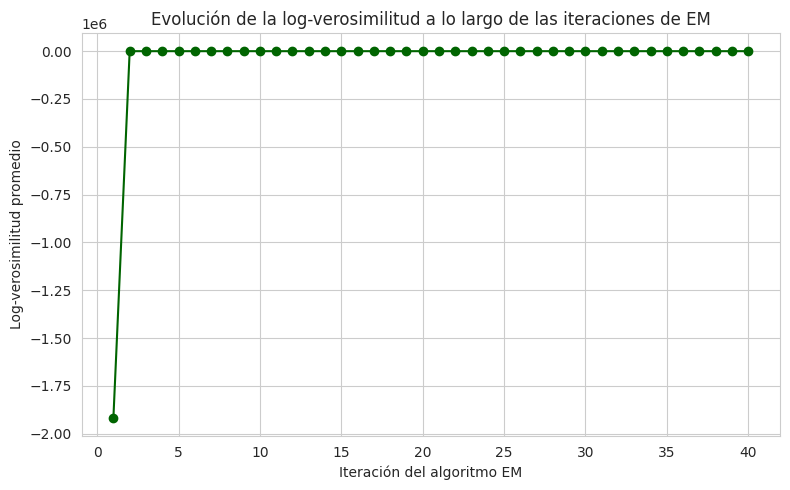

Iteraciones en las que la log-verosimilitud disminuyó: 0 de 39


In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(historial_ll) + 1), historial_ll, marker='o', color='darkgreen')
ax.set_xlabel('Iteración del algoritmo EM')
ax.set_ylabel('Log-verosimilitud promedio')
ax.set_title('Evolución de la log-verosimilitud a lo largo de las iteraciones de EM')
plt.tight_layout()
plt.show()

diferencias = np.diff(historial_ll)
print(f"Iteraciones en las que la log-verosimilitud disminuyó: {(diferencias < -1e-10).sum()} de {len(diferencias)}")


La log-verosimilitud aumenta o se mantiene en las iteraciones observadas, como se espera del algoritmo EM. También se nota que una parte importante de la mejora ocurre durante las primeras iteraciones.


## 10. Sensibilidad a la inicialización

El algoritmo EM puede converger a diferentes óptimos locales dependiendo de los valores iniciales. Por eso se comparan dos formas de inicialización de `GaussianMixture`, utilizando 10 semillas para cada una y fijando `n_init=1`. De esta manera se puede observar la variabilidad entre ejecuciones.

- **`'random'`**: los parámetros iniciales se generan sin utilizar una estructura obtenida previamente de los datos.
- **`'k-means++'`**: los centros iniciales se seleccionan buscando una separación adecuada entre ellos, proporcionando un punto de partida que puede favorecer la convergencia hacia soluciones con mejor ajuste.



In [21]:
resultados_init = []
for semilla in range(10):
    gm_rand = GaussianMixture(n_components=4, covariance_type='full', n_init=1,
                               init_params='random', random_state=semilla, max_iter=300)
    gm_rand.fit(X_scaled)
    resultados_init.append({'semilla': semilla, 'inicialización': 'random',
                             'log_verosimilitud': gm_rand.lower_bound_, 'n_iter': gm_rand.n_iter_})

    gm_kpp = GaussianMixture(n_components=4, covariance_type='full', n_init=1,
                              init_params='k-means++', random_state=semilla, max_iter=300)
    gm_kpp.fit(X_scaled)
    resultados_init.append({'semilla': semilla, 'inicialización': 'k-means++',
                             'log_verosimilitud': gm_kpp.lower_bound_, 'n_iter': gm_kpp.n_iter_})

init_df = pd.DataFrame(resultados_init)
resumen_init = init_df.groupby('inicialización')['log_verosimilitud'].agg(['mean', 'std', 'min', 'max'])
print(resumen_init.round(4))


                  mean     std     min     max
inicialización                                
k-means++       2.4469  0.1523  2.1119  2.5441
random         -3.3598  0.0689 -3.4416 -3.3028


/tmp/ipykernel_34933/3237329648.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=init_df, x='inicialización', y='log_verosimilitud', ax=ax,


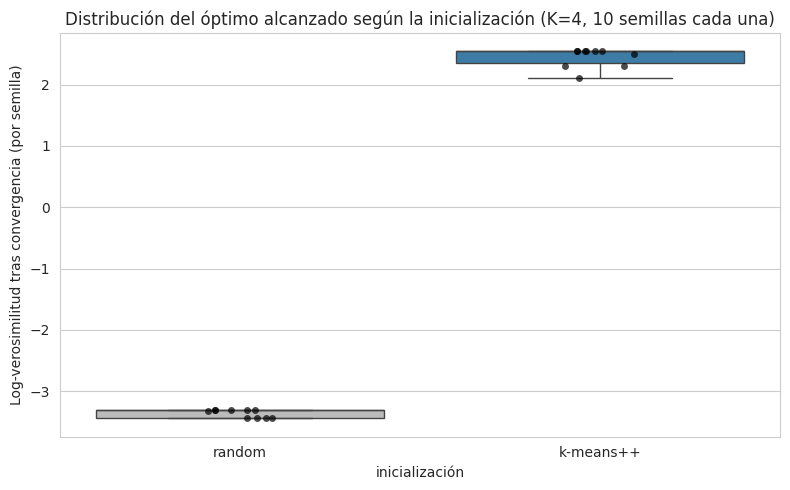

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=init_df, x='inicialización', y='log_verosimilitud', ax=ax,
            palette={'random': '#bbbbbb', 'k-means++': '#2c7fb8'})
sns.stripplot(data=init_df, x='inicialización', y='log_verosimilitud', color='black', alpha=0.7, ax=ax)
ax.set_ylabel('Log-verosimilitud tras convergencia (por semilla)')
ax.set_title('Distribución del óptimo alcanzado según la inicialización (K=4, 10 semillas cada una)')
plt.tight_layout()
plt.show()


En las semillas evaluadas, la inicialización `'random'` obtiene valores de log-verosimilitud inferiores a los obtenidos con `'k-means++'`. También se observa cierta variación entre las diferentes semillas, lo que muestra que el punto de partida sí puede afectar el resultado de EM.

A partir de esto se decide utilizar `'k-means++'` en el modelo final y realizar varios reinicios mediante `n_init=20`. Así se tienen varias inicializaciones y se conserva la solución con mayor log-verosimilitud, reduciendo el riesgo de quedarse en una solución local de peor ajuste.



## 11. Modelo final

Con la selección de $K=4$ y la comparación de las estrategias de inicialización, se ajusta el modelo final utilizando `k-means++` y 20 reinicios (`n_init=20`).



In [23]:
gm_final = GaussianMixture(n_components=4, covariance_type='full', n_init=20,
                            init_params='k-means++', random_state=RANDOM_STATE, max_iter=500)
gm_final.fit(X_scaled)

print(f"Convergió: {gm_final.converged_}")
print(f"Iteraciones hasta convergencia: {gm_final.n_iter_}")
print(f"Log-verosimilitud promedio final: {gm_final.lower_bound_:.4f}")
print(f"BIC: {gm_final.bic(X_scaled):,.1f}")
print(f"AIC: {gm_final.aic(X_scaled):,.1f}")
print(f"Pesos de mezcla (pi_k): {np.round(gm_final.weights_, 4)}")


Convergió: True
Iteraciones hasta convergencia: 27
Log-verosimilitud promedio final: 2.7406
BIC: -217,716.1
AIC: -218,429.3
Pesos de mezcla (pi_k): [0.219  0.3031 0.1911 0.2868]


## 12. Caracterización de los perfiles latentes

Cada viaje tiene una responsabilidad $\gamma_{ik}$ para cada uno de los cuatro perfiles. Por eso, para describir cada componente no se utilizan únicamente los viajes que tienen la mayor probabilidad de pertenencia.

En su lugar, se calculan promedios ponderados por las responsabilidades. También se obtiene el tamaño efectivo de cada perfil:

$$
N_k = \sum_i \gamma_{ik}
$$

Esto permite tener en cuenta la incertidumbre del modelo al momento de describir los perfiles.



In [24]:
responsabilidades = gm_final.predict_proba(X_scaled)
df_clean['perfil_dominante'] = responsabilidades.argmax(axis=1)
df_clean['responsabilidad_max'] = responsabilidades.max(axis=1)

def media_ponderada(col, pesos):
    return np.average(df_clean[col], weights=pesos)

filas = []
for k in range(4):
    w = responsabilidades[:, k]
    Nk = w.sum()
    filas.append({
        'Perfil': k,
        'Peso (pi_k)': gm_final.weights_[k],
        'N efectivo': Nk,
        '% de la muestra': Nk / len(df_clean) * 100,
        'Hora media de recogida': media_ponderada('horas_pickup', w),
        '% fin de semana': media_ponderada('is_weekend', w) * 100,
        'Duración media (min)': media_ponderada('trip_duration', w),
        'Distancia media (km)': media_ponderada('distancia_haversine_km', w),
        'Velocidad media (km/h)': media_ponderada('velocidad_promedio_kmh', w),
    })

tabla_perfiles = pd.DataFrame(filas).set_index('Perfil').round(2)
tabla_perfiles


,Peso (pi_k),N efectivo,% de la muestra,Hora media de recogida,% fin de semana,Duración media (min),Distancia media (km),Velocidad media (km/h)
Perfil,,,,,,,,
0,0.22,8683.05,21.78,13.72,0.0,24.67,7.55,19.54
1,0.30,12175.85,30.54,14.39,0.0,11.77,2.10,12.00
2,0.19,7579.10,19.01,13.51,0.0,7.09,0.92,10.86
3,0.29,11437.00,28.68,12.65,100.0,12.78,3.50,15.86


**Lectura de los perfiles resultantes:**

| Perfil | Denominación | Características |
|---|---|---|
| **0** | Viajes largos entre semana | Presenta las mayores duraciones y distancias, con valores aproximados de 25 min y 7.5 km. También tiene la velocidad promedio más alta, cercana a 19.5 km/h. Este comportamiento es compatible con desplazamientos entre zonas más alejadas o con viajes hacia el aeropuerto durante días laborales. |
| **1** | Viajes estándar entre semana | Tiene valores intermedios de duración y distancia, alrededor de 12 min y 2.1 km. Es el perfil con mayor tamaño y representa el comportamiento más frecuente dentro de los viajes entre semana. |
| **2** | Viajes cortos entre semana | Agrupa viajes de menor duración y distancia, aproximadamente 7 min y 0.9 km, junto con una velocidad promedio cercana a 11 km/h. Son desplazamientos de corta distancia que pueden estar asociados a zonas de mayor densidad o congestión. |
| **3** | Viajes de fin de semana | Su responsabilidad está concentrada principalmente en viajes realizados durante el fin de semana. Presenta valores intermedios de duración y distancia, aproximadamente 13 min y 3.5 km, diferenciándose del comportamiento observado durante los días laborales. |




## 13. Visualización de los perfiles



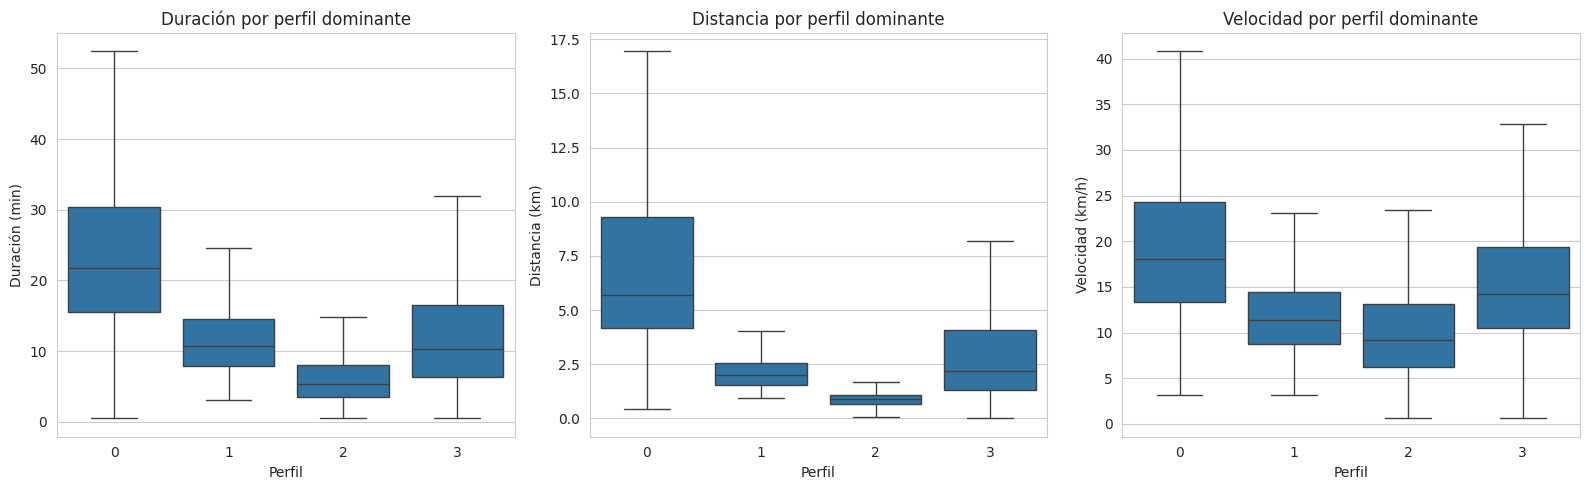

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df_clean, x='perfil_dominante', y='trip_duration', ax=axes[0], showfliers=False)
axes[0].set_title('Duración por perfil dominante')
axes[0].set_xlabel('Perfil'); axes[0].set_ylabel('Duración (min)')

sns.boxplot(data=df_clean, x='perfil_dominante', y='distancia_haversine_km', ax=axes[1], showfliers=False)
axes[1].set_title('Distancia por perfil dominante')
axes[1].set_xlabel('Perfil'); axes[1].set_ylabel('Distancia (km)')

sns.boxplot(data=df_clean, x='perfil_dominante', y='velocidad_promedio_kmh', ax=axes[2], showfliers=False)
axes[2].set_title('Velocidad por perfil dominante')
axes[2].set_xlabel('Perfil'); axes[2].set_ylabel('Velocidad (km/h)')

plt.tight_layout()
plt.show()


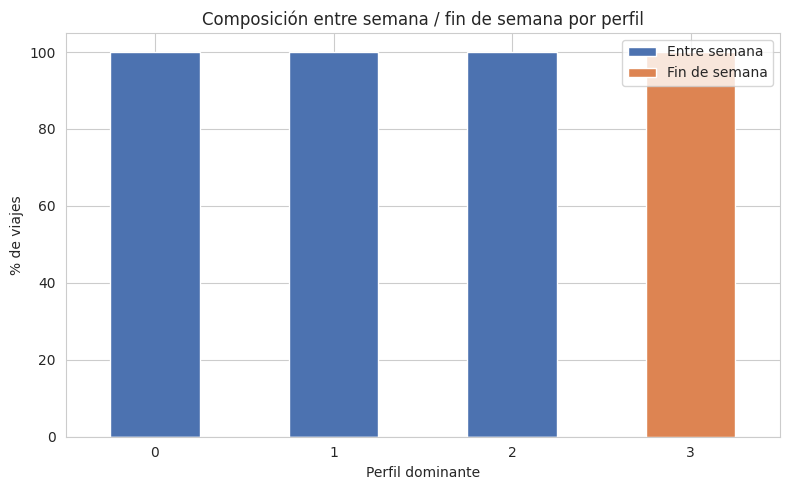

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))
tabla_weekend = pd.crosstab(df_clean['perfil_dominante'], df_clean['is_weekend'], normalize='index') * 100
tabla_weekend.columns = ['Entre semana', 'Fin de semana']
tabla_weekend.plot(kind='bar', stacked=True, ax=ax, color=['#4c72b0', '#dd8452'])
ax.set_xlabel('Perfil dominante'); ax.set_ylabel('% de viajes')
ax.set_title('Composición entre semana / fin de semana por perfil')
ax.legend(title=None)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Un resultado interesante es que la hora de recogida no es la variable que más diferencia los perfiles. Las horas promedio de recogida son relativamente parecidas entre los cuatro grupos, mientras que las diferencias más claras aparecen en la duración, la distancia, la velocidad y la condición de fin de semana.

Por lo tanto, para este conjunto de datos parece más útil hablar de tipos de viaje y de fin de semana que dividir los viajes únicamente según la hora del día.

## 14. Coclusiones operativas

 A partir de los perfiles encontrados se pueden plantear las siguientes consideraciones para UrbanMove:

1. **La diferencia entre días laborales y fines de semana es importante.** El modelo identifica un perfil asociado principalmente al fin de semana, por lo que podría ser útil considerar calendarios de operación diferentes para estos dos periodos en lugar de utilizar un único patrón promedio.

2. **Dentro de los días laborales aparecen tres tipos de viaje.** Se observan viajes cortos, estándar y largos, diferenciados principalmente por duración, distancia y velocidad. Esta separación muestra que la demanda entre semana no tiene un único comportamiento.

3. **Las responsabilidades pueden ser útiles para la asignación de recursos.** Cuando un viaje tiene probabilidades similares entre dos perfiles, asignarlo de manera rígida a uno solo puede ocultar parte de la información. Las responsabilidades permiten conservar esa incertidumbre al analizar la demanda.

4. **La inicialización afecta el resultado del modelo.** Los experimentos realizados muestran diferencias entre las inicializaciones. Por eso, si el modelo se vuelve a entrenar periódicamente, utilizar varios reinicios puede ayudar a obtener soluciones más estables.





## 15. Tabla resumen de parámetros del modelo



In [27]:
tabla_convergencia = pd.DataFrame({
    'Métrica': ['Tipo de covarianza', 'Inicialización', 'Semilla',
                'Convergió', 'Iteraciones hasta convergencia',
                'Log-verosimilitud promedio', 'BIC', 'AIC'],
    'Valor': ['full', "k-means++ (n_init=20)", RANDOM_STATE,
              gm_final.converged_, gm_final.n_iter_,
              round(gm_final.lower_bound_, 4),
              round(gm_final.bic(X_scaled), 1),
              round(gm_final.aic(X_scaled), 1)]
})
tabla_convergencia

,Métrica,Valor
0,Tipo de covarianza,full
1,Inicialización,k-means++ (n_init=20)
2,Semilla,42
3,Convergió,True
4,Iteraciones hasta convergencia,27
5,Log-verosimilitud promedio,2.7406
6,BIC,-217716.1
7,AIC,-218429.3


In [28]:
tabla_parametros = pd.DataFrame(
    gm_final.means_, columns=FEATURES
).round(3)
tabla_parametros.insert(0, 'Peso (pi_k)', gm_final.weights_.round(4))
tabla_parametros.insert(1, 'N efectivo', responsabilidades.sum(axis=0).round(0).astype(int))
tabla_parametros.index = [f'Perfil {k}' for k in range(gm_final.n_components)]
tabla_parametros.index.name = 'Perfil'
tabla_parametros

,Peso (pi_k),N efectivo,horas_pickup,is_weekend,log_duration,log_distancia,log_velocidad
Perfil,,,,,,,
Perfil 0,0.2190,8683,0.023,-0.634,0.955,1.204,0.638
Perfil 1,0.3031,12176,0.128,-0.634,-0.041,-0.255,-0.249
Perfil 2,0.1911,7579,-0.012,-0.634,-0.875,-1.014,-0.623
Perfil 3,0.2868,11437,-0.144,1.577,-0.103,0.026,0.191


In [29]:
tabla_convergencia.to_csv('rol3_convergencia.csv', index=False)
tabla_parametros.to_csv('rol3_parametros_finales.csv')